# Import Libraries and read file

In [1]:
import pandas as pd
import os

low_x0, low_y0, low_w, low_h, bottom_z, top_z = -500, -500, 1000, 1000, -500, 500

def get_velz_dens(x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

def get_velx_vely(x_range, y_range, z_range):
    # read a 3D grid of vely and density array
    vely = obj["flash", "vely"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    velx = obj["flash", "velx"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    
    print(f"velx.shape: {velx.shape}\tvely.shape: {vely.shape}\n\n")      
    
    return velx, vely

# convert seconds to Megayears
def seconds_to_megayears(seconds):
    return seconds / (1e6 * 365 * 24 * 3600)

def pc2pixel(coord, x_y_z):
    if x_y_z == "x":
        return coord + top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord + top_z
    return coord

def pixel2pc(coord, x_y_z):
    if x_y_z == "x":
        return coord - top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord - top_z
    return coord

def cm2pc(cm):
    return cm * 3.24077929e-19

# filter the DataFrame
def filter_data(df, range_coord):
    return df[(df['posx_pc'] > range_coord[0]) & (df['posx_pc'] < range_coord[0] + range_coord[2]) & (df['posy_pc'] > range_coord[1]) & (df['posy_pc'] < range_coord[1] + range_coord[3]) & (df['posz_pc'] > range_coord[4] & (df['posz_pc'] < range_coord[5]))]

def timestamp2Myr(timestamp):
    return (timestamp - 200) * 0.1 + 191

def time_Myr2timestamp(time_Myr):
    return round(10 * (time_Myr - 191) + 200)

In [2]:
import matplotlib.pyplot as plt
import astropy
import yt
import numpy as np
import os 
from matplotlib.patches import Rectangle
from matplotlib import cm
import matplotlib.colors as colors

# elephant
# hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"

# mac
hdf5_root = "~/Desktop/UBC/Research/Program/Dataset/raw_hdf5"

time_Myr = 210

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim = 256
ylim = 256
zlim= 256
left_edge = arb_center + ds.quan(-500, 'pc')
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(256,256,256))

yt : [INFO     ] 2024-07-05 14:03:50,583 Parameters: current_time              = 6627195108709764.0
yt : [INFO     ] 2024-07-05 14:03:50,584 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-07-05 14:03:50,585 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-07-05 14:03:50,586 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-07-05 14:03:50,587 Parameters: cosmological_simulation   = 0


In [3]:
# retrieve the center (100, 100, 100) grid, zoom in the explosion


# Multiply each element within the tuples by the multiplier
x_range_scaled = (100, 200) #tuple(int(x * multiplier) for x in x_range)
y_range_scaled = (128, 228) #(28, 128) #tuple(int(y * multiplier) for y in y_range)
#z_range_scaled = z_range  
z_range_scaled = (91, 191)
# z_range_scaled = (65, 217) #tuple(int(z * multiplier) for z in z_range)

center_x, center_y, center_z = int(pc2pixel(85, x_y_z="x") * 256/1000), int(pc2pixel(196, x_y_z="x") * 256/1000), int(pc2pixel(53, x_y_z="z") * 256/1000)
print(center_x, center_y, center_z, time_Myr)

center_x = center_x - x_range_scaled[0]
center_y = center_y - y_range_scaled[0]
center_z = center_z - z_range_scaled[0]

new_velz, new_dens, new_temp = get_velz_dens(x_range_scaled, y_range_scaled, z_range_scaled)
new_velx, new_vely = get_velx_vely(x_range_scaled, y_range_scaled, z_range_scaled)


149 178 141 210
obj.shape: (256, 256, 256)
x, y, z ranges:  (100, 200) (128, 228) (91, 191)
velz.shape: (100, 100, 100)	dens.shape: (100, 100, 100)


velx.shape: (100, 100, 100)	vely.shape: (100, 100, 100)




## Edge Mask generation
- Density slice
    - threholding, then connected component
    - keep only the center mask, or SB230 that we wanted
- Ring Mask
    - dilate then subtract the original mask
    - retrieve the ring mask for each slice (repeat for all slices the blob span)  

In [4]:
import cv2
def apply_otsus_thresholding(image):
    # _, threshold = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # return threshold
    _, binary_image = cv2.threshold(image.astype("uint8"), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return cv2.bitwise_not(binary_image)

def within_range(min, max, target):
    if min < target and max > target:
        return True
    return False

def SN_center_in_bubble(posx_px, posy_px, x1, y1, w, h):
    if within_range(x1, x1 + w, posx_px) and within_range(y1, y1 + h, posy_px):
        return True
    return False

def normalize4thresholding(arr):
    slice = np.log10(arr)
    return ((slice - np.min(slice)) / (np.max(slice) - np.min(slice))) * 255 

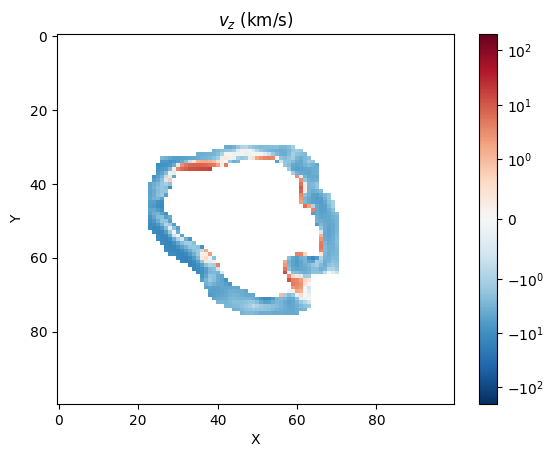

In [56]:
# read density slice
lower_b = 0
upper_b = 100
input_point = (center_x, center_y)
mask = np.zeros((100, 100, upper_b - lower_b))
dilated_stack = np.zeros((100, 100, upper_b - lower_b))

for current_z in range(upper_b - lower_b):
    dens_slice = normalize4thresholding(new_dens[:, :, current_z + lower_b]) 

    # cv2.imwrite(f"tmp/dens_{current_z}.png", dens_slice)
    # dens_img = cv2.imread(f"tmp/dens_{current_z}.png")
    
    # threshold + connected component
    binary_mask = apply_otsus_thresholding(dens_slice)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    # Check each component's bounding box to find the target mask
    for i in range(3, num_labels):  # Starting from 1 to ignore the background
        x, y, w, h, area = stats[i]
        
        # Check if the center point is within the bounding box
        if SN_center_in_bubble(input_point[0], input_point[1], x, y, w, h):     # and area < 10 * 427
            # If yes, fill the target_mask with this component
            binary_mask = labels == i
            
            # Save the target mask
            mask[:, :, current_z] = binary_mask
            target_mask = np.where(labels == i, 255, 0).astype('uint8')

            break 


    # dilate the binary mask for 3 pixels
    kernel = np.ones((10, 10), np.uint8)
    
    # outside mask
    dilated_mask = cv2.dilate(target_mask, kernel, iterations=1)
    dilated_stack[:, :, current_z] = dilated_mask

    # subtract the dilated mask with the original binary mask to retrieve the boundary edge for the sphere
boundary_edge = np.logical_xor(mask, dilated_stack).astype(float)

# cast the ring of mask over velz and dens array, plot out the velocity profile, with integrated density as a function of velz  
velz_roi = np.where(boundary_edge, new_velz[:, :, lower_b:upper_b], np.nan)
dens_roi = np.where(boundary_edge, new_dens[:, :, lower_b:upper_b], np.nan)

# plt.plot(velz_roi[:, center_y, 25].T)
plt.imshow(velz_roi[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
plt.colorbar()

plt.title('$v_z$ (km/s)')
plt.xlabel('X')
plt.ylabel('Y')
# plt.savefig(f'graphs/{time_Myr}/ringed_velz_{center_z}.png')
plt.show()



In [86]:
# organized the ring mask coordinates into dictionary, one slice per record

ringed_stack = {}

for z in range(upper_b - lower_b):
    ringed_mask = {'coord_x': [], 'coord_y': [],'velz': [], 'dens': []}
    binary_mask = boundary_edge[:, :, z]
    coords = np.where(binary_mask == 1)

 
    # coords = np.column_stack(np.where(binary_mask == 1))

    velz_values = velz_roi[coords[0], coords[1], z + lower_b]
    dens_values = dens_roi[coords[0], coords[1], z + lower_b]

    # print(coords[0].size)


    ringed_mask['coord_x'].extend(coords[0].tolist())
    ringed_mask['coord_y'].extend(coords[1].tolist())
    
    ringed_mask['velz'].extend(velz_values.tolist())
    ringed_mask['dens'].extend(dens_values.tolist())

    ringed_stack[z] = ringed_mask